# Quasiparticle interference maps
Let us see what a single impurity does to the local density of states of a two-dimensional
metal, with `h.get_qpi_impurity()`. The impurity scatters an electron from a state at momentum
$\vec k$ to a state at $\vec k'$ of the same energy, and the two interfere, so that the local
density of states around the impurity is modulated with wavevector $\vec q=\vec k-\vec k'$. The
Fourier transform of that modulation is what is called the quasiparticle interference (QPI)
pattern, and it is what an STM measurement obtains by Fourier transforming a conductance map.
`h.get_qpi_impurity()` does it the way the experiment does: it builds a supercell of `h`, puts
explicit impurities in it, computes the real-space LDOS map around them, and Fourier transforms
that map. It returns the positions of the sites and the LDOS on them, and the q-points and the
QPI weight on them; `write=False` keeps it from writing the same data to disk.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### A point impurity in a square lattice
We put one onsite impurity in a $30\times30$ supercell of the square lattice and compute the
LDOS and its Fourier transform at two energies close to the top of the band, where the
constant-energy contour is a small closed line around $\Gamma$. The supercell size sets the q
resolution, since exactly $30\times30$ q-points of the Brillouin zone are commensurate with it.
The strongest scattering is backscattering, from $\vec k$ to $-\vec k$, which has $\vec q=2\vec k$,
so the QPI should light up on the constant-energy contour scaled by two: the dashed line is the
contour $\epsilon(\vec q/2)=E$, computed from the Bloch Hamiltonian.

site-packages/scipy/sparse/linalg/_eigen/arpack/arpack.py:1664: RuntimeWarning: k >= N - 1 for N * N square matrix. Attempting to use scipy.linalg.eig instead.
  ret = eigs(A, k, M=M, sigma=sigma, which=which, v0=v0,


Switch to dense


site-packages/scipy/sparse/linalg/_eigen/arpack/arpack.py:1664: RuntimeWarning: k >= N - 1 for N * N square matrix. Attempting to use scipy.linalg.eig instead.
  ret = eigs(A, k, M=M, sigma=sigma, which=which, v0=v0,


Switch to dense


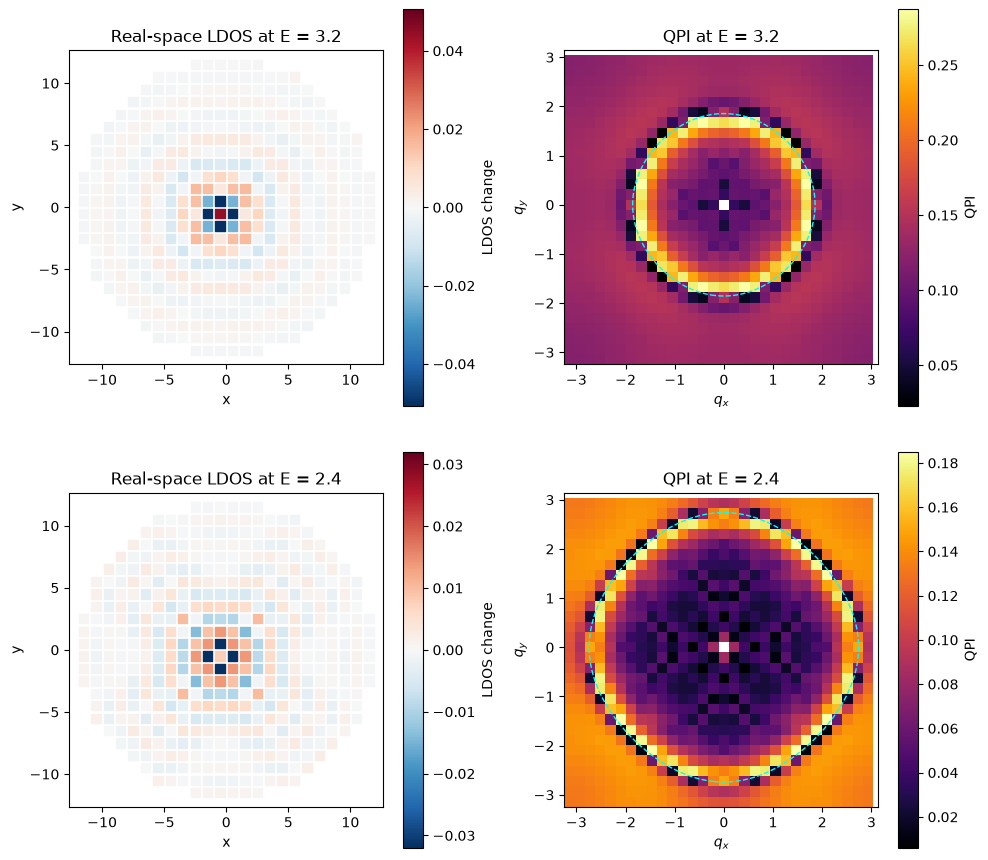

In [2]:
g = geometry.square_lattice() # square lattice
h = g.get_hamiltonian(has_spin=False) # spinless Hamiltonian
energies = [3.2,2.4] # energies of the maps
n = 30 # supercell size
r,ldos_r,q,qpi_q = h.get_qpi_impurity(nsuper=n, # 30x30 supercell
        impurities=[{"position": [0.,0.,0.], "onsite": 3.0}], # one impurity
        energies=energies,num_waves=80,nk=2,delta=0.1,write=False)

hk = h.get_hk_gen() # Bloch Hamiltonian, k in units of the reciprocal lattice vectors
qs = np.linspace(-np.pi,np.pi,121)
eq = np.array([[hk([x/(4*np.pi),y/(4*np.pi),0.])[0,0].real for x in qs] for y in qs]) # e(q/2)

near = np.linalg.norm(r,axis=1)<12. # sites close to the impurity
far = np.linalg.norm(r,axis=1)>0.5 # every site but the impurity
qx,qy = q[:,0].reshape(n,n),q[:,1].reshape(n,n) # the q-mesh is a regular grid
fig,axs = plt.subplots(2,2,figsize=(10,9))
for i,e in enumerate(energies):
    ax = axs[i,0]
    dl = ldos_r[i] - np.mean(ldos_r[i][far]) # change of the LDOS
    v = np.max(np.abs(dl[far])) # color scale set by the sites around the impurity
    sc = ax.scatter(r[near,0],r[near,1],c=dl[near],cmap="RdBu_r",vmin=-v,vmax=v,s=45,marker="s")
    fig.colorbar(sc,ax=ax,label="LDOS change")
    ax.set_aspect("equal") ; ax.set_xlabel("x") ; ax.set_ylabel("y")
    ax.set_title("Real-space LDOS at E = "+str(e))
    ax = axs[i,1]
    c = qpi_q[i].copy() ; c[np.linalg.norm(q,axis=1)<1e-6] = np.nan # drop q=0, the total DOS
    pm = ax.pcolormesh(qx,qy,c.reshape(n,n),shading="nearest",cmap="inferno")
    fig.colorbar(pm,ax=ax,label="QPI")
    ax.contour(qs,qs,eq,levels=[e],colors="cyan",linewidths=1,linestyles="--") # q = 2k
    ax.set_aspect("equal") ; ax.set_xlabel("$q_x$") ; ax.set_ylabel("$q_y$")
    ax.set_title("QPI at E = "+str(e))
plt.tight_layout()
plt.show()

The real-space maps show the Friedel oscillations of the LDOS around the impurity, concentric
rings whose wavelength is set by the size of the constant-energy contour, so that they become
shorter as the energy moves into the band. In the QPI maps the weight sits on a ring that
follows the dashed line, the constant-energy contour scaled by two, and the ring grows and
becomes less circular as the energy moves away from the top of the band, which is what an STM
experiment uses to reconstruct the band structure of a material from its conductance maps. The
q resolution is set by the supercell; a larger `nsuper` refines the maps at the cost of a larger
diagonalization.